In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import pandas as pd
import sys
from pathlib import Path

# Add scripts to path
sys.path.insert(0, '/home/student/s/ssahu/share/aigm-classifier/scripts')

data_dir = "/home/student/s/ssahu/share/aigm-classifier/data"
cached_spec_dir = f"{data_dir}/cached_spectrograms"

# Load spectrograms from directory structure (label subdirectories)
spec_data = []
for label_dir in os.listdir(cached_spec_dir):
    label_path = os.path.join(cached_spec_dir, label_dir)
    if os.path.isdir(label_path):
        label = int(label_dir)
        for spec_file in sorted(os.listdir(label_path)):
            if spec_file.endswith('.npy'):
                spec_path = os.path.join(label_path, spec_file)
                spec_data.append({
                    'label': label,
                    'spectrogram_path': spec_path,
                    'filename': spec_file
                })

df = pd.DataFrame(spec_data).sort_values('spectrogram_path').reset_index(drop=True)

if len(df) > 0:
    print(f"✅ Loaded {len(df)} cached spectrograms")
    print(f"\nLabel distribution:")
    print(df['label'].value_counts().sort_index())
    print(f"\nFirst 5 samples:")
    print(df.head())
else:
    print(f"❌ No spectrograms found in {cached_spec_dir}")

✅ Loaded 49984 cached spectrograms

Label distribution:
label
0    24984
1    25000
Name: count, dtype: int64

First 5 samples:
   label                                   spectrogram_path    filename
0      0  /home/student/s/ssahu/share/aigm-classifier/da...  000000.npy
1      0  /home/student/s/ssahu/share/aigm-classifier/da...  000001.npy
2      0  /home/student/s/ssahu/share/aigm-classifier/da...  000002.npy
3      0  /home/student/s/ssahu/share/aigm-classifier/da...  000003.npy
4      0  /home/student/s/ssahu/share/aigm-classifier/da...  000007.npy


📊 Sample 33005:
   Label: 1
   Shape: (1, 128, 216)
   Path: /home/student/s/ssahu/share/aigm-classifier/data/cached_spectrograms/1/016069.npy
   Min: -1.74, Max: 3.66


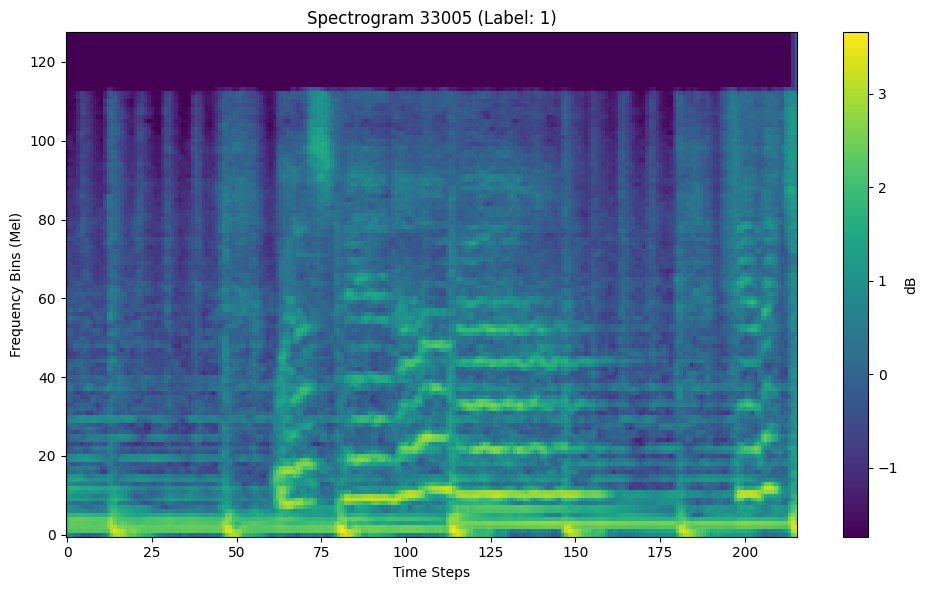

In [4]:
def load_spectrogram(idx):
    """Load a single spectrogram by index from the dataframe."""
    if idx >= len(df):
        print(f"❌ Index {idx} out of range (max: {len(df)-1})")
        return None
    
    row = df.iloc[idx]
    spec_path = row['spectrogram_path']
    label = row['label']
    
    if not os.path.exists(spec_path):
        print(f"❌ File not found: {spec_path}")
        return None
    
    spec = np.load(spec_path)
    return spec, label, spec_path

# Choose an index to view (e.g., the first one)
sample_idx = 33005
spec, label, path = load_spectrogram(sample_idx)

if spec is not None:
    print(f"📊 Sample {sample_idx}:")
    print(f"   Label: {label}")
    print(f"   Shape: {spec.shape}")
    print(f"   Path: {path}")
    print(f"   Min: {spec.min():.2f}, Max: {spec.max():.2f}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(spec[0], cmap='viridis', origin='lower', aspect='auto')
    plt.title(f"Spectrogram {sample_idx} (Label: {label})")
    plt.colorbar(label='dB')
    plt.xlabel("Time Steps")
    plt.ylabel("Frequency Bins (Mel)")
    plt.tight_layout()
    plt.show()

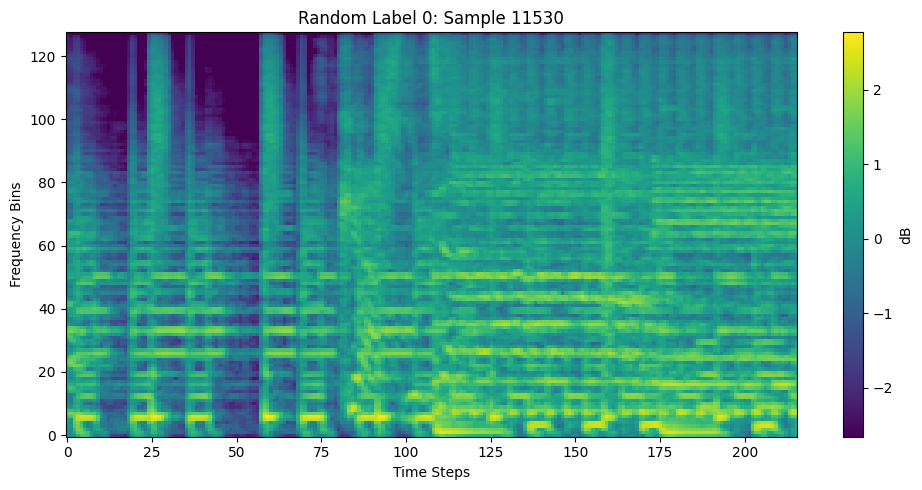

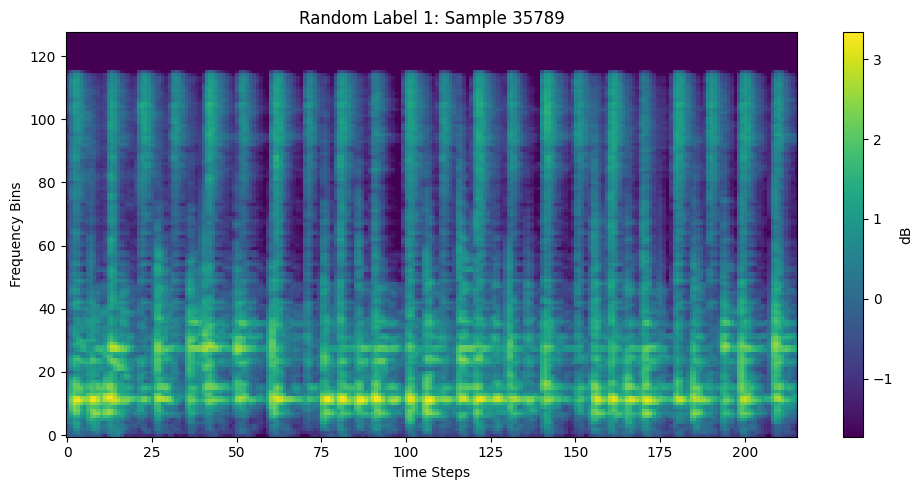

In [5]:
# Browse random samples
import random

# Pick random samples from each label
for label in [0, 1]:
    label_samples = df[df['label'] == label].sample(11)
    idx = label_samples.index[0]
    spec, lbl, path = load_spectrogram(idx)
    
    if spec is not None:
        plt.figure(figsize=(10, 5))
        plt.imshow(spec[0], cmap='viridis', origin='lower', aspect='auto')
        plt.title(f"Random Label {label}: Sample {idx}")
        plt.colorbar(label='dB')
        plt.xlabel("Time Steps")
        plt.ylabel("Frequency Bins")
        plt.tight_layout()
        plt.show()

In [6]:
# Load audio from trainset and compute spectrograms
import librosa
import librosa.display

trainset_dir = "/home/student/s/ssahu/share/aigm-classifier/data/trainset"
manifest_path = os.path.join(trainset_dir, "manifest.csv")

# Load manifest
if os.path.exists(manifest_path):
    trainset_manifest = pd.read_csv(manifest_path)
    print(f"✅ Loaded trainset manifest: {len(trainset_manifest)} samples")
    print(trainset_manifest.head())
else:
    print(f"❌ Manifest not found: {manifest_path}")
    print("\nChecking directory structure:")
    for root, dirs, files in os.walk(trainset_dir):
        level = root.replace(trainset_dir, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files in each dir
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more files')

✅ Loaded trainset manifest: 50000 samples
                                            filepath  label    source  \
0  /share/users/student/s/ssahu/aigm-classifier/d...      0  fma_real   
1  /share/users/student/s/ssahu/aigm-classifier/d...      0  fma_real   
2  /share/users/student/s/ssahu/aigm-classifier/d...      0  fma_real   
3  /share/users/student/s/ssahu/aigm-classifier/d...      0  fma_real   
4  /share/users/student/s/ssahu/aigm-classifier/d...      1       NaN   

  generator format  sample_rate   duration  notes  
0       NaN    mp3      44100.0  30.002698    NaN  
1       NaN    mp3      44100.0  30.002698    NaN  
2       NaN    mp3      44100.0  29.976576    NaN  
3       NaN    mp3      44100.0  30.002698    NaN  
4  musicldm    wav      16000.0  10.000000    NaN  


In [7]:
# Build list of audio files from trainset
audio_files = {'real': [], 'fake': []}

real_dir = os.path.join(trainset_dir, "real")
fake_dir = os.path.join(trainset_dir, "fake")

for label_type, label_dir in [("real", real_dir), ("fake", fake_dir)]:
    if os.path.exists(label_dir):
        for root, dirs, files in os.walk(label_dir):
            for file in files:
                if file.lower().endswith(('.wav', '.mp3', '.flac', '.ogg')):
                    audio_files[label_type].append(os.path.join(root, file))

print(f"✅ Found {len(audio_files['real'])} real audio files")
print(f"✅ Found {len(audio_files['fake'])} fake audio files")

if len(audio_files['real']) > 0:
    print(f"\nFirst 3 real samples:")
    for f in audio_files['real'][:3]:
        print(f"  {os.path.basename(f)}")

if len(audio_files['fake']) > 0:
    print(f"\nFirst 3 fake samples:")
    for f in audio_files['fake'][:3]:
        print(f"  {os.path.basename(f)}")

✅ Found 26000 real audio files
✅ Found 27605 fake audio files

First 3 real samples:
  000002.mp3
  000003.mp3
  000005.mp3

First 3 fake samples:
  -0SdAVK79lg.wav
  -0xzrMun0Rs.wav
  -1OlgJWehn8.wav


In [ ]:
# Function to load audio and compute mel-spectrogram
def load_and_process_audio(audio_path, sr=16000, n_mels=128):
    """Load audio file and compute mel-spectrogram."""
    try:
        # Load audio
        y, sr_loaded = librosa.load(audio_path, sr=sr)
        
        # Compute mel-spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        return y, sr, S_db
    except Exception as e:
        print(f"❌ Error loading {audio_path}: {e}")
        return None, None, None

# Test with one real and one fake sample
print("🎵 Loading audio samples from trainset...\n")

samples_to_visualize = {
    'real': audio_files['real'][0] if audio_files['real'] else None,
    'fake': audio_files['fake'][0] if audio_files['fake'] else None
}

audio_data = {}
for label, audio_path in samples_to_visualize.items():
    if audio_path:
        y, sr, S_db = load_and_process_audio(audio_path)
        if y is not None:
            audio_data[label] = {'audio': y, 'sr': sr, 'spectrogram': S_db, 'path': audio_path}
            print(f"✅ {label.upper()}: {os.path.basename(audio_path)}")
            print(f"   Duration: {len(y) / sr:.2f}s, Sample rate: {sr} Hz")
            print(f"   Spectrogram shape: {S_db.shape}")
        else:
            print(f"❌ Failed to load {label} sample")
    else:
        print(f"⚠️  No {label} samples found")

🎵 Loading audio samples from trainset...

✅ REAL: 000002.mp3
   Duration: 29.98s, Sample rate: 44100 Hz
   Spectrogram shape: (128, 2582)
✅ FAKE: -0SdAVK79lg.wav
   Duration: 10.18s, Sample rate: 44100 Hz
   Spectrogram shape: (128, 877)


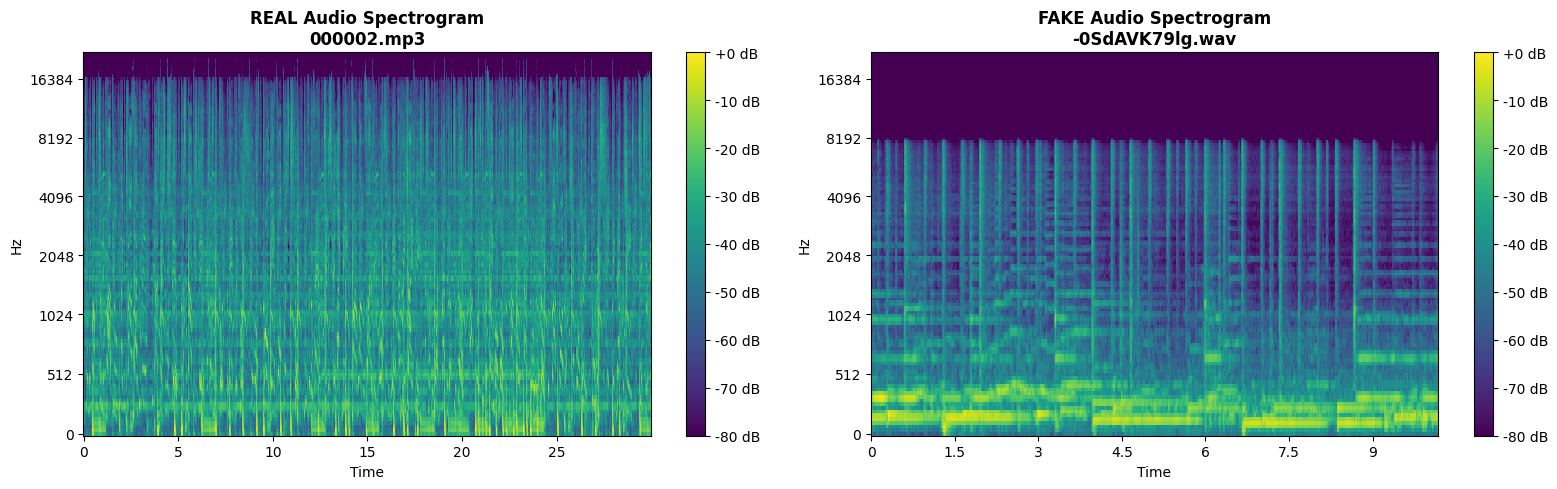


📊 Spectrogram Comparison:
  Real shape: (128, 2582)
  Fake shape: (128, 877)


In [15]:
# Visualize spectrograms side by side
if len(audio_data) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for idx, (label, data) in enumerate(audio_data.items()):
        S_db = data['spectrogram']
        
        # Display spectrogram
        img = librosa.display.specshow(S_db, sr=data['sr'], hop_length=512, 
                                       x_axis='time', y_axis='mel', 
                                       ax=axes[idx], cmap='viridis')
        axes[idx].set_title(f"{label.upper()} Audio Spectrogram\n{os.path.basename(data['path'])}", 
                            fontsize=12, fontweight='bold')
        fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Spectrogram Comparison:")
    print(f"  Real shape: {audio_data['real']['spectrogram'].shape}")
    print(f"  Fake shape: {audio_data['fake']['spectrogram'].shape}")
else:
    print("⚠️  Need at least 2 samples to compare")

🎵 Browsing random samples from trainset...



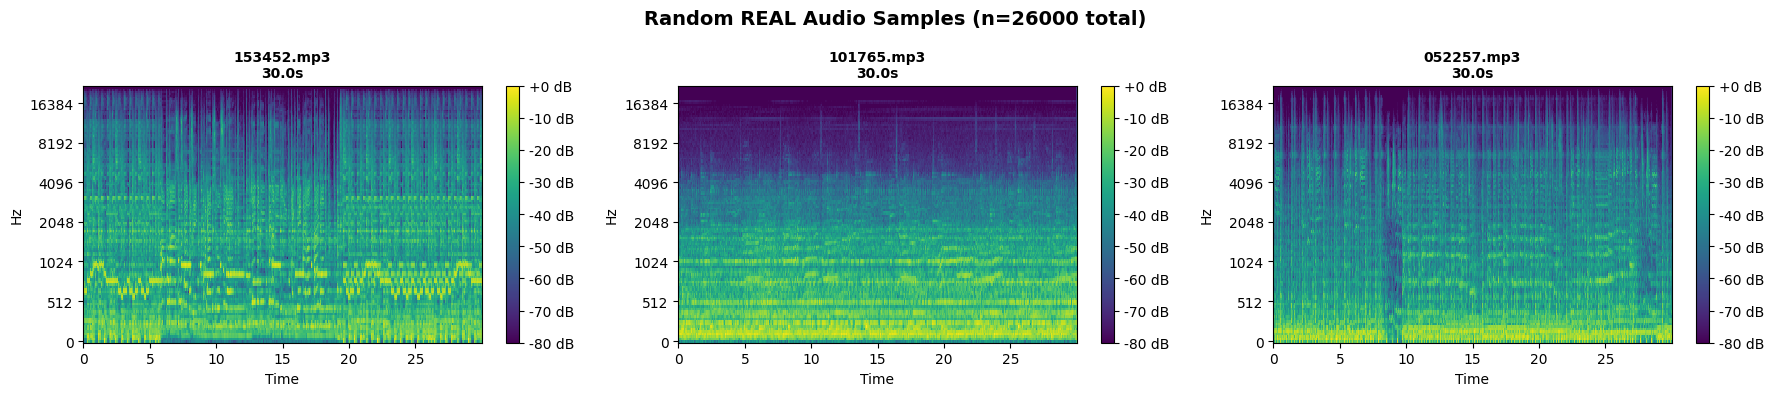

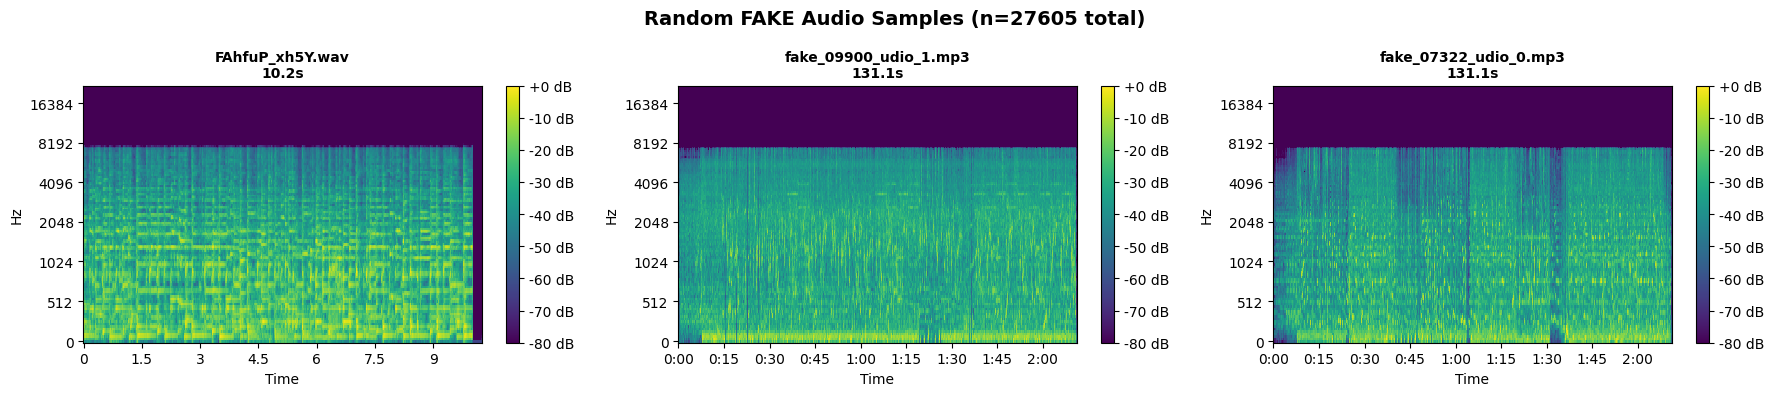

In [16]:
# Browse multiple random samples from trainset
import random

print("🎵 Browsing random samples from trainset...\n")

# Create a grid of spectrograms
for label_type in ['real', 'fake']:
    if not audio_files[label_type]:
        print(f"⚠️  No {label_type} samples available")
        continue
    
    # Pick 3 random samples
    random_samples = random.sample(audio_files[label_type], min(3, len(audio_files[label_type])))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    for plot_idx, audio_path in enumerate(random_samples):
        y, sr, S_db = load_and_process_audio(audio_path)
        
        if y is not None:
            img = librosa.display.specshow(S_db, sr=sr, hop_length=512,
                                          x_axis='time', y_axis='mel',
                                          ax=axes[plot_idx], cmap='viridis')
            axes[plot_idx].set_title(f"{os.path.basename(audio_path)}\n{len(y)/sr:.1f}s", 
                                     fontsize=10, fontweight='bold')
            fig.colorbar(img, ax=axes[plot_idx], format='%+2.0f dB')
    
    fig.suptitle(f"Random {label_type.upper()} Audio Samples (n={len(audio_files[label_type])} total)", 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()